In [52]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

#splitting the dataset 
df=pd.read_csv('./dataset/train.csv')
df.fillna(0)

selected_features = [
    'wtd_std_ThermalConductivity',
    'range_ThermalConductivity',
    'range_atomic_radius',
    'std_ThermalConductivity',
    'wtd_mean_Valence',
    'wtd_entropy_atomic_mass',
    'wtd_gmean_Valence',
    'wtd_entropy_atomic_radius',
    'number_of_elements',
    'range_fie',
    'mean_Valence',
    'wtd_std_atomic_radius',
    'entropy_Valence',
    'wtd_entropy_Valence',
    'wtd_std_fie',
    'gmean_Valence',
    'entropy_fie',
    'wtd_entropy_FusionHeat',
    'std_atomic_radius',
    'gmean_Density'
]


train_set=df.sample(frac=0.75,random_state=445)
test_set=df.drop(train_set.index)


y_train=train_set["critical_temp"]
x_train=train_set.drop("critical_temp",axis=1)
x_train = train_set[selected_features]
x_test = test_set[selected_features]
y_test = test_set["critical_temp"]
y_test = y_test.to_numpy()

x_train = train_set[selected_features].copy()
x_test = test_set[selected_features].copy()

for feature in selected_features:
    x_train[feature + "_sq"] = x_train[feature] ** 2
    x_test[feature + "_sq"] = x_test[feature] ** 2




#scaling the Dataset
median=x_train.median()
q1 = x_train.quantile(0.25)
q3= x_train.quantile(0.75)
iqr=q3-q1

x_train_scaled= (x_train-median)/iqr
x_test_scaled = (x_test - median) / iqr

X=x_train_scaled.to_numpy()
X_test = x_test_scaled.to_numpy()
Y=y_train.to_numpy()

m,n=X.shape
theta=np.zeros(n)
alpha=0.01
iterations=1000



print(f"Shape of X: {m,n}")
print(f"Shape of y: {Y.shape}")

df.head()



Shape of X: (15947, 40)
Shape of y: (15947,)


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


C:\Users\praim\AppData\Local\Temp\ipykernel_13480\262169612.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,ax = plt.subplots(1,1, figsize=(5,6))


IndexError: list index out of range

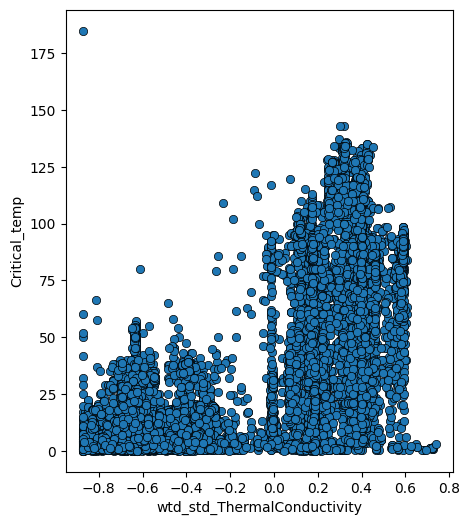

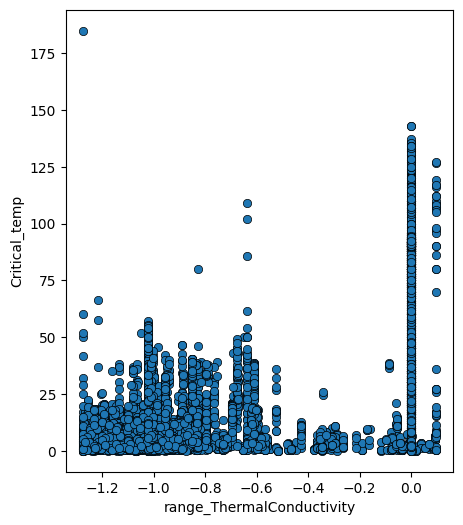

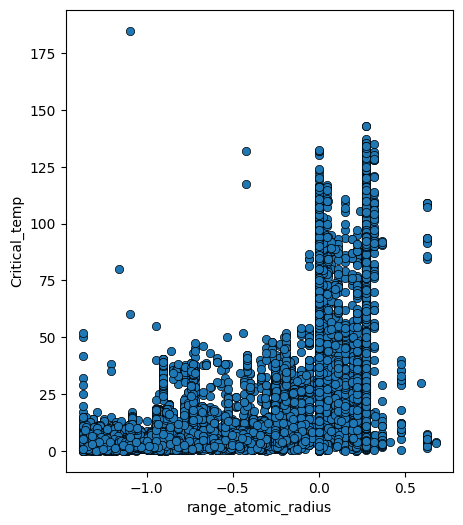

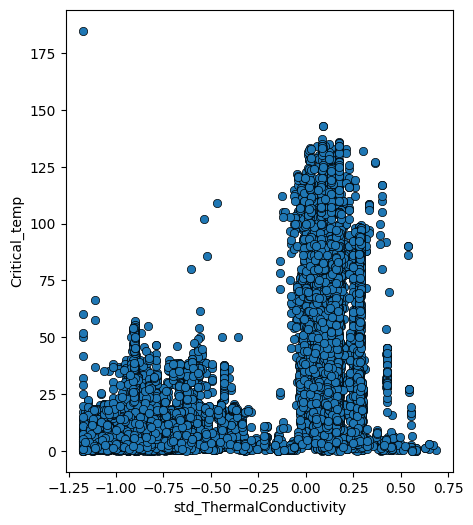

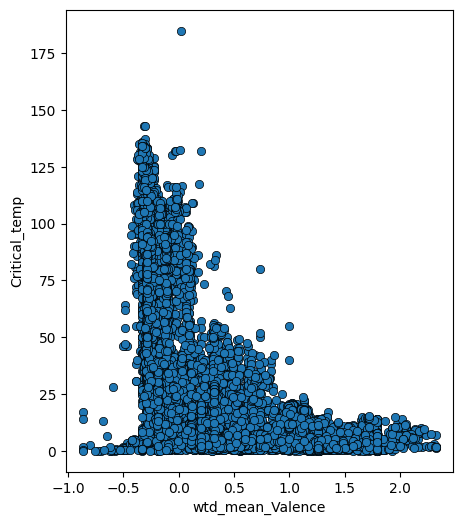

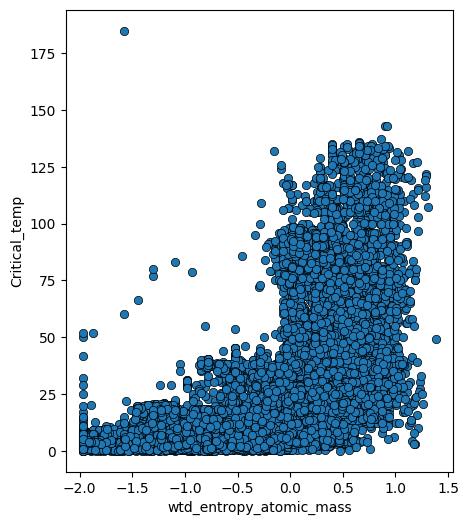

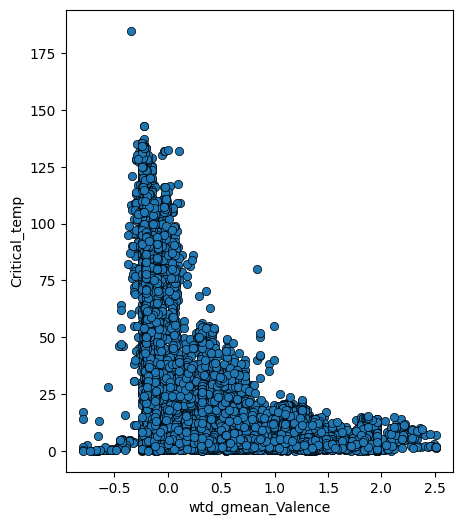

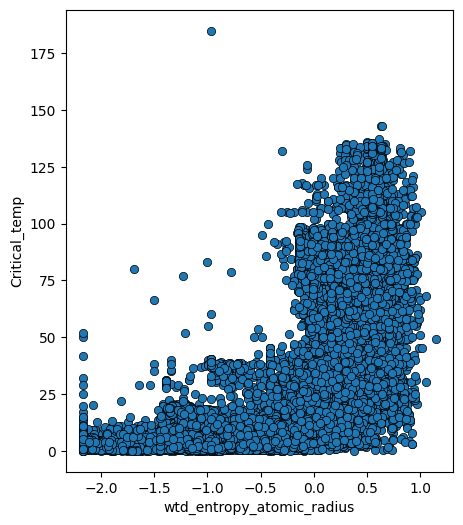

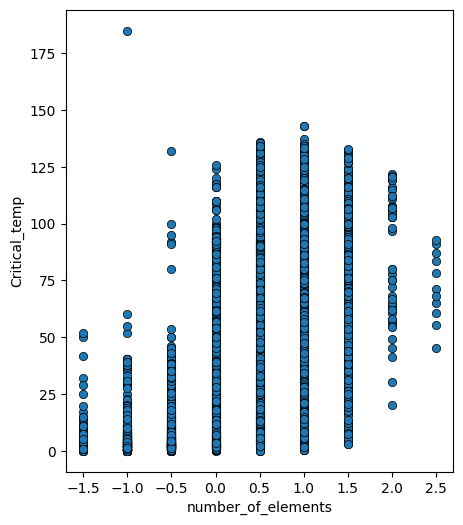

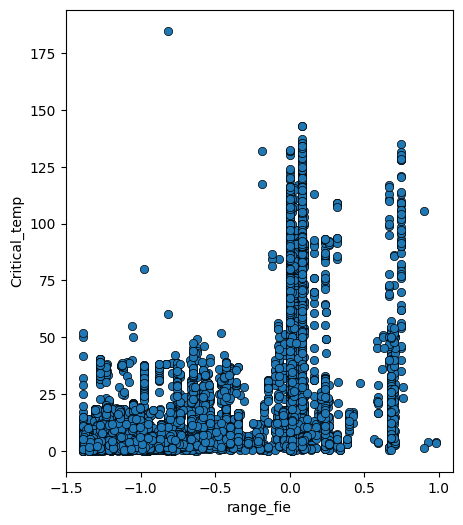

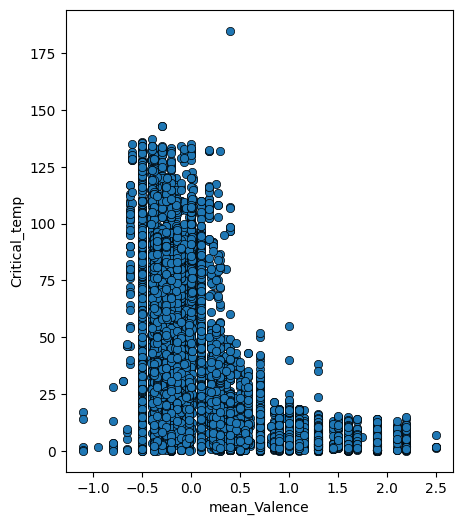

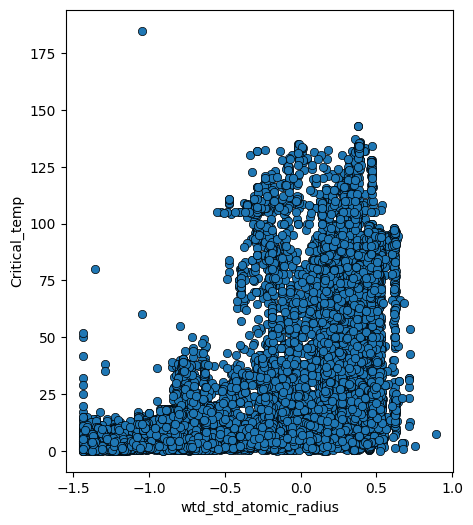

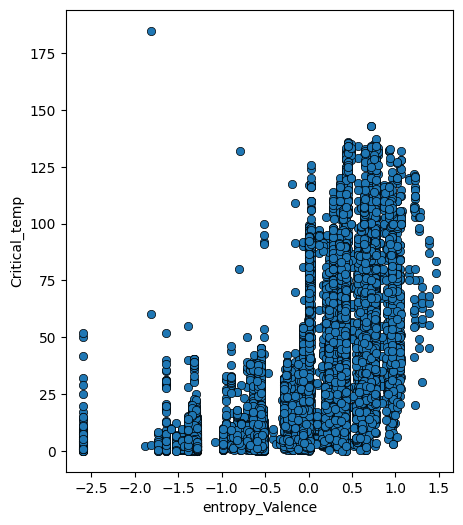

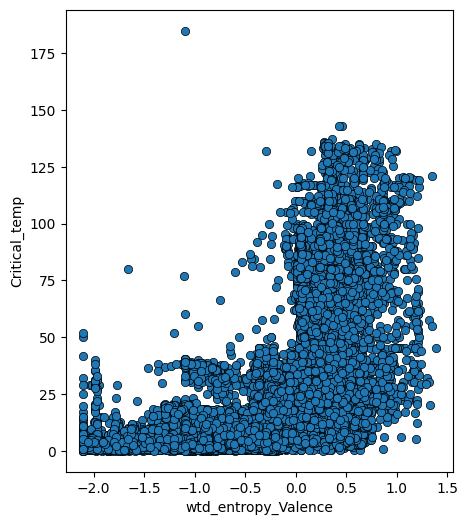

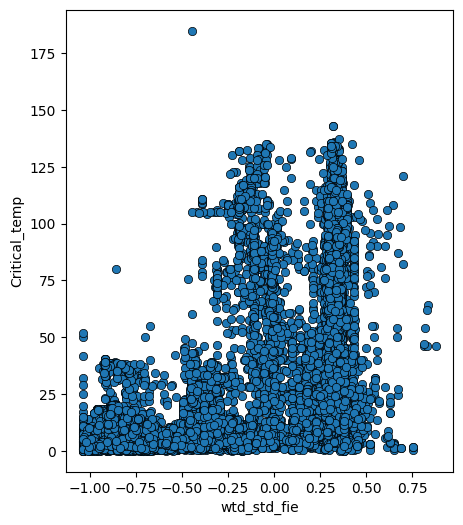

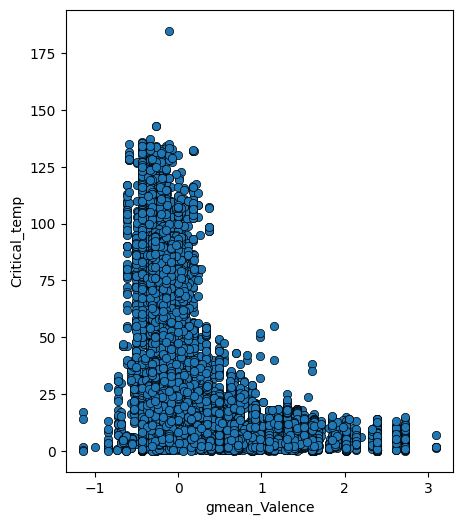

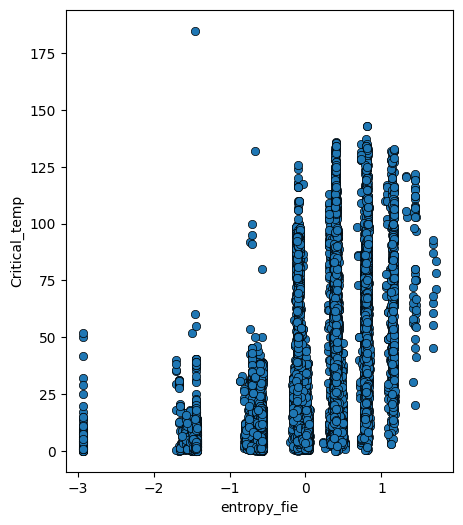

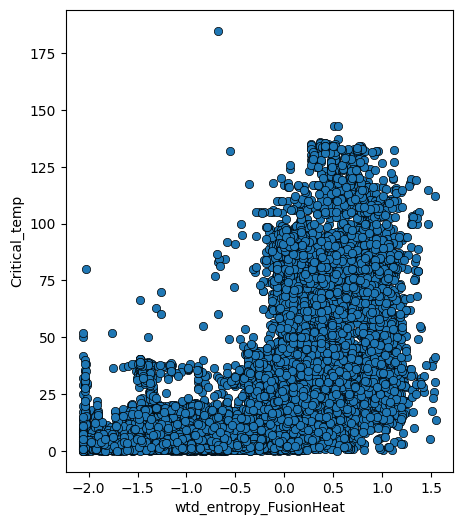

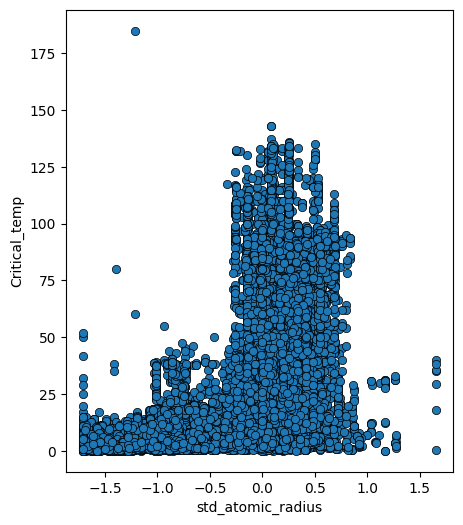

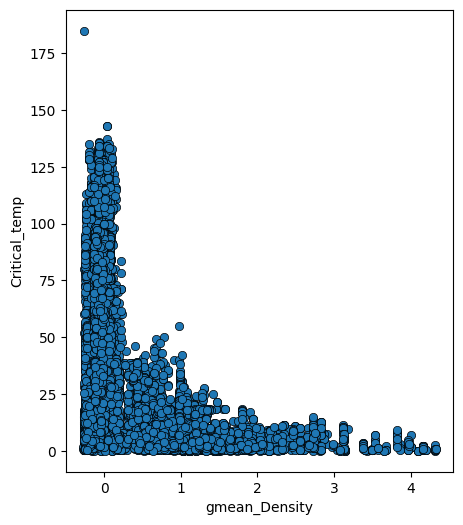

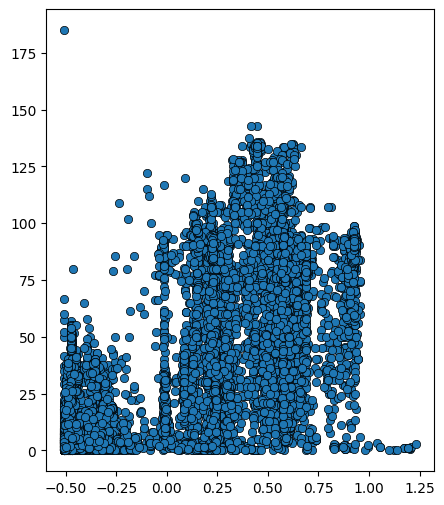

In [53]:

for i in range (X.shape[1]):
    fig,ax = plt.subplots(1,1, figsize=(5,6))
    ax.scatter(X[:,i], Y, marker='o', edgecolors='black', linewidths=0.5)
    ax.set_xlabel(selected_features[i])
    ax.set_ylabel("Critical_temp")

In [54]:
#compute_cost
def compute_cost(X,y, w, b):
    cost = 0.0

    for i in range(X.shape[0]):
        f_wb = np.dot(X[i], w) + b
        cost += (f_wb - y[i])**2

    return cost/(2*X.shape[0])



#compute_gradient
def compute_gradient(X, y, w, b):
    m, n = X.shape

    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        f_wb = np.dot(X[i], w) + b
        error = f_wb - y[i]

        dj_db += error

        for j in range(n):
            dj_dw[j] += error * X[i, j]

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

**Gradient_Descent**

In [55]:
def gradient_descent(X_train, y_train, compute_cost, compute_gradient, l_rate, iter, w_i, b_i):

    J_hist = []
    param_hist = []
    iteration = []
    b = b_i
    w = w_i


    for i in range(iter):
        dj_dw,dj_db = compute_gradient(X_train,y_train, w, b)

        w = w - (dj_dw * l_rate)
        b = b - (dj_db * l_rate)

       

        if(i%(math.ceil(iter/10)) == 0):
            iteration.append(i)
            J_hist.append(compute_cost(X_train, y_train, w,b))
            param_hist.append([w,b])
            print(f"iteration: {i} || Cost: {J_hist[-1]}")

            
    return w,b, J_hist, param_hist, iteration





In [56]:


def viewCost(J_hist, iteration, param_hist):
    plt.plot(iteration, J_hist)
    plt.title("Cost Function Over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Cost (J)")
    plt.show()




In [57]:
w_i = np.zeros((n,))
b_i = 0.0
w,b, J_hist, param_hist, iteration = gradient_descent(X,Y,compute_cost, compute_gradient, 0.01, iterations,w_i,b_i)


iteration: 0 || Cost: 1149.9922972264017
iteration: 100 || Cost: 353.4209168957103
iteration: 200 || Cost: 275.3218257277932
iteration: 300 || Cost: 254.2648764484356


KeyboardInterrupt: 

[np.float64(1168.1482788715846), np.float64(426.9084344111928), np.float64(322.3434590576769), np.float64(292.1754516734101), np.float64(279.0645267720564), np.float64(271.8884097887529), np.float64(267.334673578492), np.float64(264.13309098643), np.float64(261.70236456043864), np.float64(259.74265767650337)]


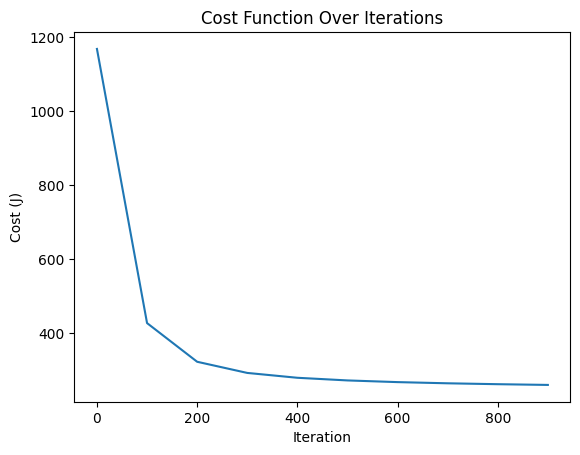

In [47]:
print(J_hist)
viewCost(J_hist, iteration, param_hist)
# print(w.shape)
# print(J_hist.size())


In [48]:
def predict(X,w,b):
    return np.dot(X,w) + b

[50.06733855 52.19137386 49.62505628 ...  9.16601496 10.08584225
  4.68877873]


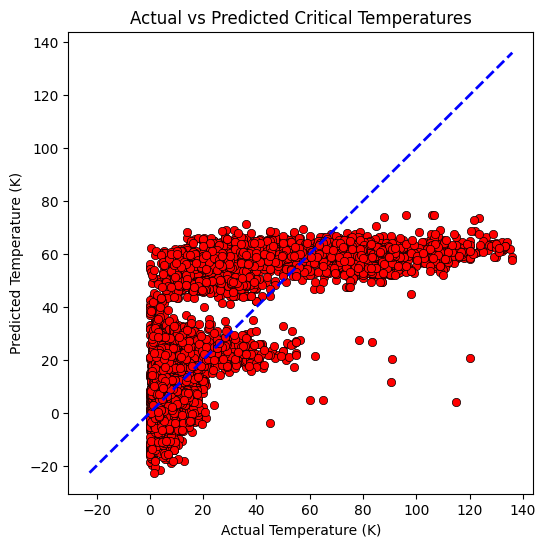

In [49]:
y_pred = predict(X_test, w, b)
print(y_pred)

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred,
    color='red',
    edgecolors='black',
    linewidths=0.5
)


min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'b--',
    linewidth=2
)

plt.title("Actual vs Predicted Critical Temperatures")
plt.xlabel("Actual Temperature (K)")
plt.ylabel("Predicted Temperature (K)")


plt.show()

In [50]:
ss_res = np.sum((y_test - y_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)

r2 = 1 - (ss_res/ss_tot)

print("R² =", r2)

R² = 0.5574149515888306


In [ ]:
train_pred = predict(X, w, b)

train_mse = np.mean((Y - train_pred)**2)
test_mse = np.mean((y_test - y_pred)**2)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

Train MSE: 516.2059010004907
Test MSE: 507.3538432611526
